# A two-sector I-HANK model

**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
- 2. [Steady state](#toc2_)    
- 3. [Compute Jacobians](#toc3_)    
- 4. [Foreign demand shock](#toc4_)    
- 5. [Response in consumption to different shocks](#toc5_)    
- 6. [Decomposing consumption response](#toc6_)    
- 7. [Fixed vs floating exchange rate](#toc7_)    
- 8. [Decomposing consumption response under fixed exchange rate](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [23]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt   
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

from IHANKModel import IHANKModelClass

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. <a id='toc1_'></a>[Setup](#toc0_)

In [24]:
model = IHANKModelClass(name='baseline')

In [25]:
model.info()

settings:
 par.py_hh = False
 par.py_blocks = False
 par.full_z_trans = False
 par.warnings = True
 par.T = 500

households:
 grids_hh: [a]
 pols_hh: [a]
 inputs_hh: [beta,ra,inc_TH,inc_NT]
 inputs_hh_z: []
 outputs_hh: [a,c,uc_TH,uc_NT,c_TH,c_NT]
 intertemps_hh: [vbeg_a]

aggregate:
 shocks: [ZTH,ZNT,beta,G,i_shock,rn_eu,i_shock_eu,Z_eu]
 unknowns: [CB,NNT,NTH,piWTH,piWNT,x_eu,pi_eu,i_eu]
 targets: [NKWCT_res,NKWCNT_res,clearing_YTH,clearing_YNT,eu_IS_res,eu_NKPC_res,eu_TR_res,UIP_res]

blocks (inputs -> outputs):
 eu_nk: [rn_eu,i_shock_eu,Z_eu,x_eu,pi_eu,i_eu] -> [PF_eu_s,rF_eu,M_eu_s,Y_eu,N_eu,mc_eu,eu_IS_res,eu_NKPC_res,eu_TR_res]
 mon_pol: [CB] -> [E]
 production: [ZTH,ZNT,NTH,NNT,piWTH,piWNT] -> [YTH,YNT,WTH,WNT,PTH,PNT]
 prices: [PF_eu_s,E,PTH,PNT,WTH,WNT] -> [PF,PTH_eu_s,PT,P,Q,wTH,wNT]
 inflation: [PF_eu_s,PF,PNT,PTH,PT,P,PTH_eu_s] -> [pi_F_eu_s,pi_F,pi_NT,pi_TH,pi_T,pi,pi_TH_eu_s]
 central_bank: [pi,E,i_shock,CB] -> [i,r,ra]
 government: [PNT,P,wTH,NTH,wNT,NNT,ra,G] -> [B,tau

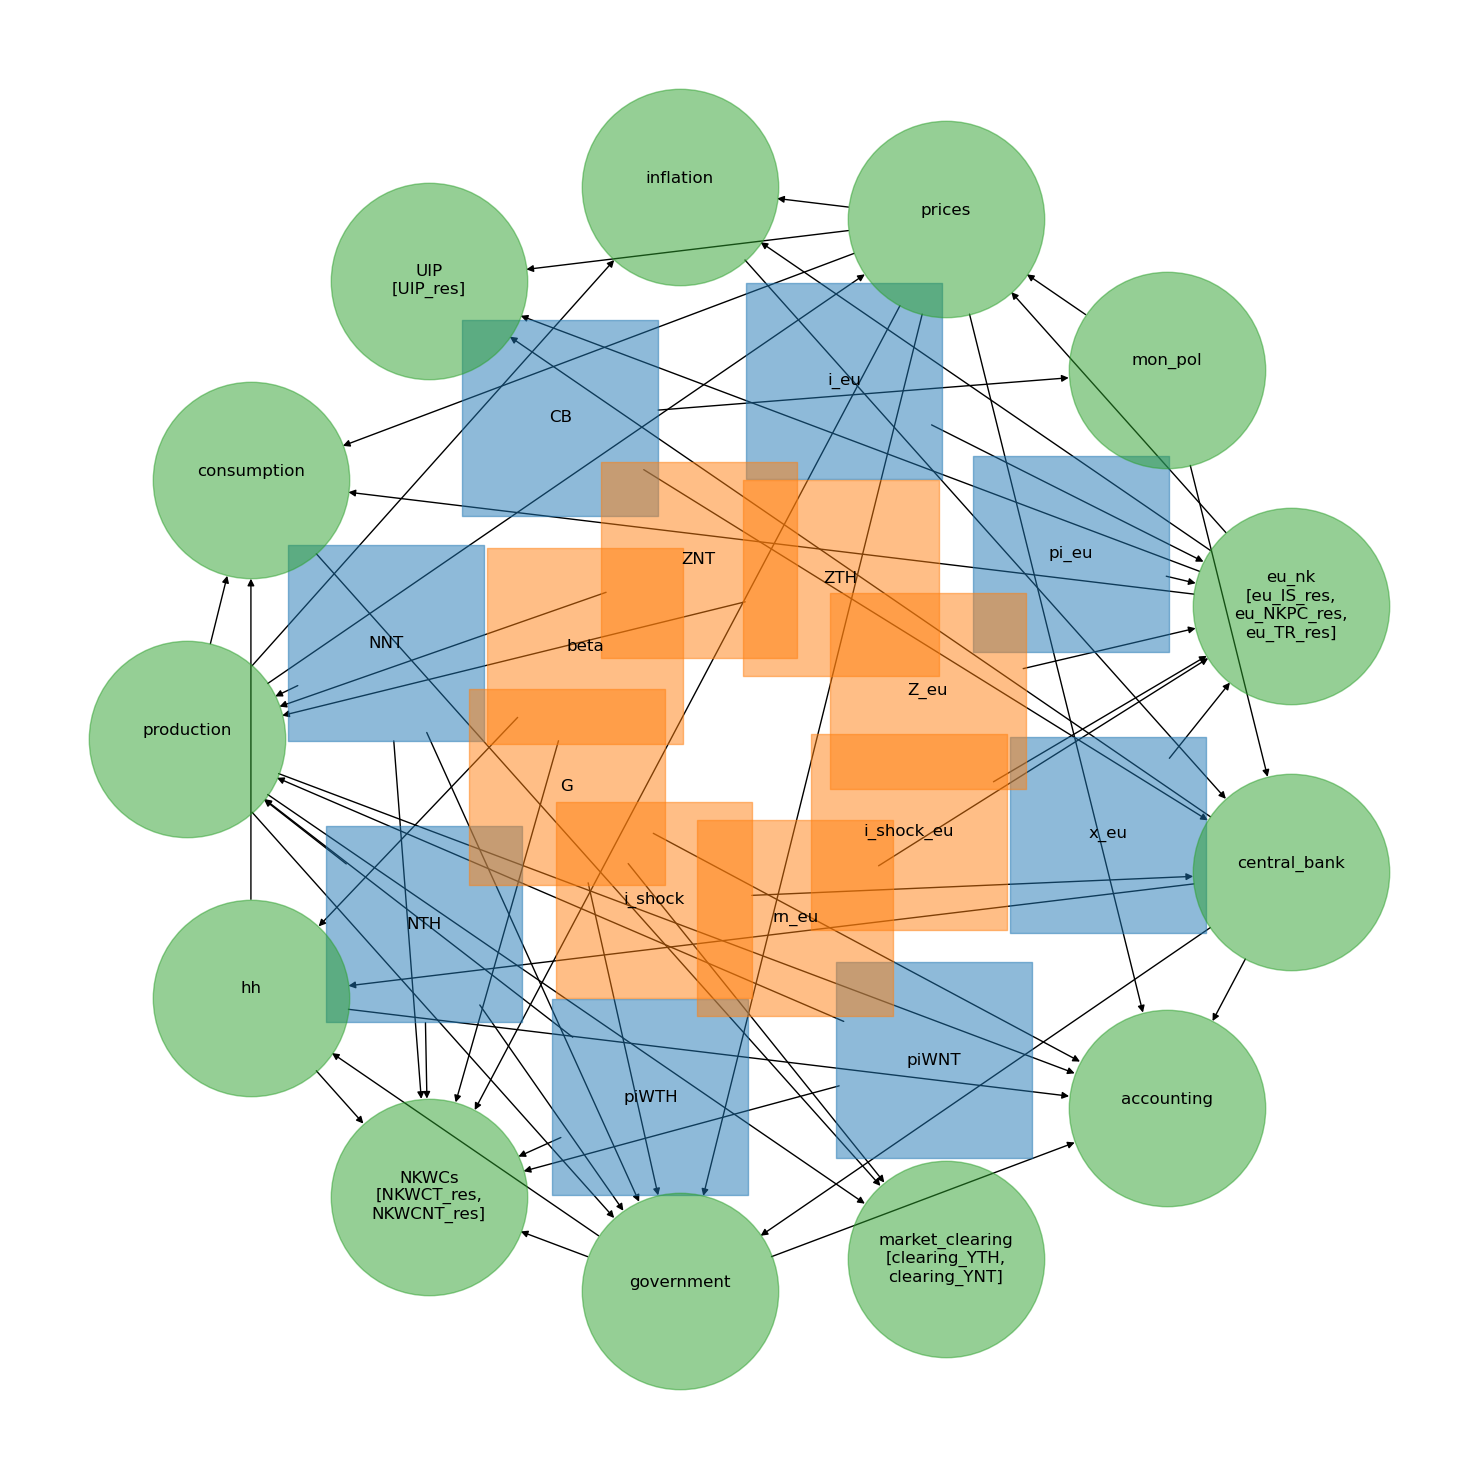

In [26]:
model.draw_DAG(figsize=(15,15),order=['shocks','unknowns','blocks'])

In [27]:
par = model.par
ss = model.ss
path = model.path
sim = model.sim

## 2. <a id='toc2_'></a>[Steady state](#toc0_)

In [28]:
model.find_ss(do_print=True)

household problem in ss solved in 5.0 secs [375 iterations]
household problem in ss simulated in 1.6 secs [419 iterations]
steady state found in 6.5 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.355
par.alphaF = 0.333
par.varphiTH = 1.271
par.varphiNT = 1.271
ss.M_eu_s = 0.083
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =   0.00000000
ss.G = 0.296
ss.NFA = 0.000


In [29]:
model.test_ss()

rn_eu          :       0.0050
i_shock_eu     :       0.0000
Z_eu           :       1.0000
x_eu           :       0.0000
pi_eu          :       0.0000
i_eu           :       0.0050
PF_eu_s        :       1.0000
rF_eu          :       0.0050
M_eu_s         :       0.0833
Y_eu           :       1.0000
N_eu           :       1.0000
mc_eu          :       1.0000
eu_IS_res      :       0.0000
eu_NKPC_res    :       0.0000
eu_TR_res      :       0.0000
E              :       1.0000
CB             :       1.0000
ZTH            :       1.0000
ZNT            :       1.0000
NTH            :       0.2500
NNT            :       0.7500
piWTH          :       0.0000
piWNT          :       0.0000
YTH            :       0.2500
YNT            :       0.7500
WTH            :       1.0000
WNT            :       1.0000
PTH            :       1.0000
PNT            :       1.0000
PF             :       1.0000
PTH_eu_s       :       1.0000
PT             :       1.0000
P              :       1.0000
Q         

In [30]:
MPC = np.sum(ss.D[:,:,:-1]*(ss.c[:,:,1:]-ss.c[:,:,:-1])/((1+ss.r)*(par.a_grid[1:]-par.a_grid[:-1])))
print(f'{MPC:.2f}')

0.32


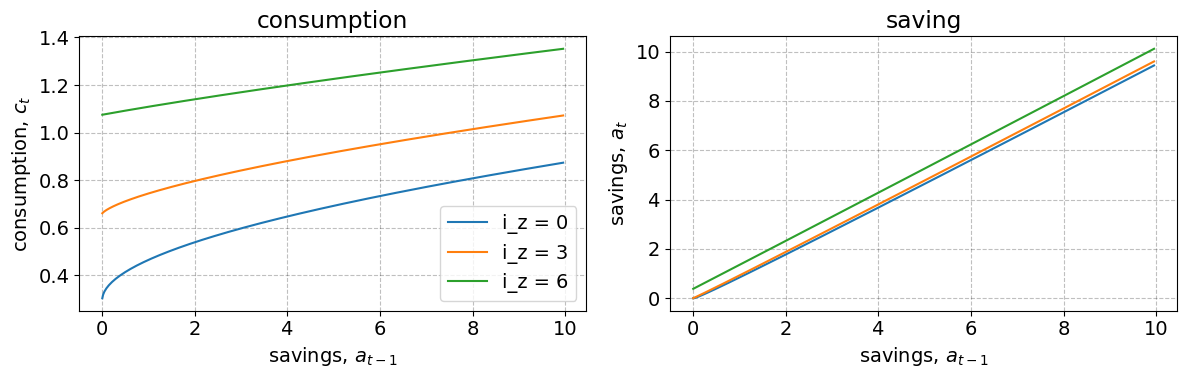

In [31]:
fig = plt.figure(figsize=(18,4),dpi=100)
a_max = 10

# a. consumption
I = par.a_grid < a_max

ax = fig.add_subplot(1,3,1)
ax.set_title(f'consumption')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.c[0,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# b. saving
I = par.a_grid < a_max

ax = fig.add_subplot(1,3,2)
ax.set_title(f'saving')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.a[0,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')

fig.tight_layout()

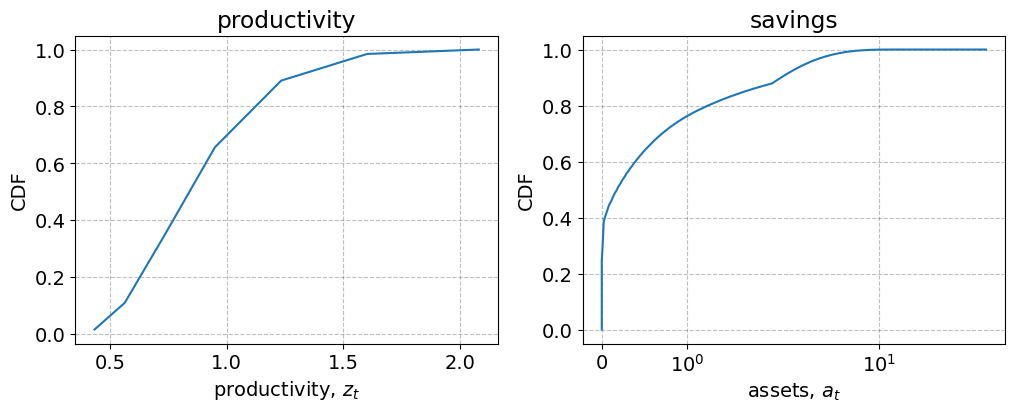

In [32]:
fig = plt.figure(figsize=(12,4),dpi=100)

# a. income
ax = fig.add_subplot(1,2,1)
ax.set_title('productivity')

y = np.cumsum(np.sum(ss.D[0],axis=1))
ax.plot(par.z_grid,y/y[-1])

ax.set_xlabel('productivity, $z_{t}$')
ax.set_ylabel('CDF')

# b. assets
ax = fig.add_subplot(1,2,2)
ax.set_title('savings')
y = np.insert(np.cumsum(np.sum(ss.D[0],axis=0)),0,0.0)
ax.plot(np.insert(par.a_grid,0,par.a_grid[0]),y/y[-1])
        
ax.set_xlabel('assets, $a_{t}$')
ax.set_ylabel('CDF')
ax.set_xscale('symlog')

## 3. <a id='toc3_'></a>[Compute Jacobians](#toc0_)

**Household transition path:**

note: inputs = steady state value -> expected: constant value (straigt line) in roughly -10^-5 to 10^5

household problem solved along transition path in 1.6 secs
household problem simulated along transition in 0.6 secs



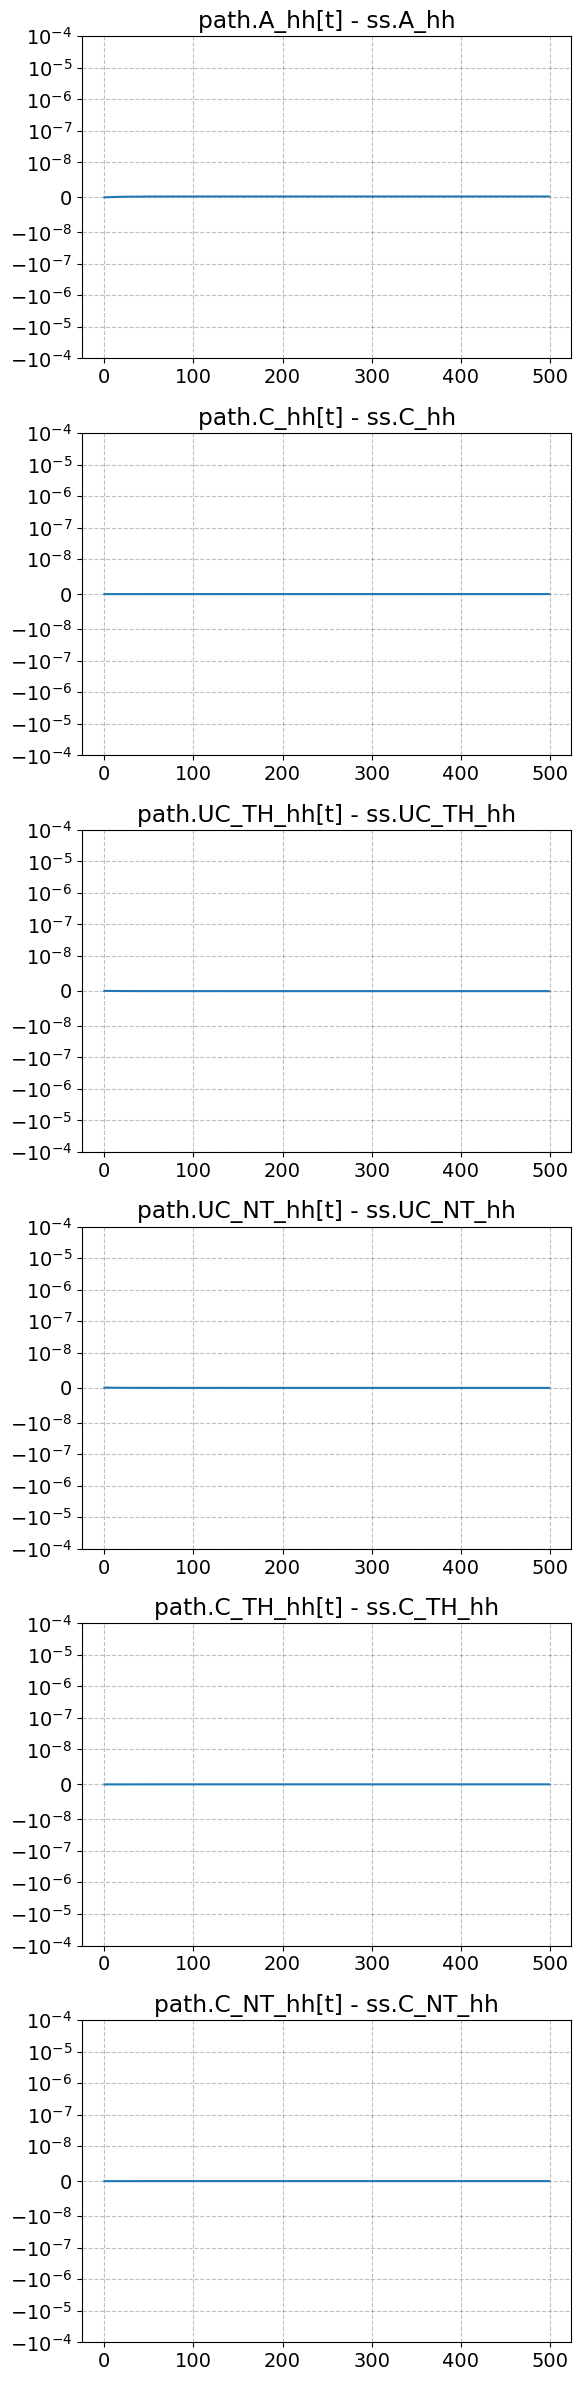

In [33]:
model.test_hh_path()

**Full transition path:**

In [34]:
model.test_path()

shocks: ZTH ZNT beta G i_shock rn_eu i_shock_eu Z_eu 
unknowns: CB NNT NTH piWTH piWNT x_eu pi_eu i_eu 

look at max(abs(path.VARNAME[:]-ss.VARNAME)):

 blocks.eu_nk
  PF_eu_s          0.0e+00
  rF_eu            1.1e-16
  M_eu_s           0.0e+00
  Y_eu             0.0e+00
  N_eu             0.0e+00
  mc_eu            0.0e+00
  eu_IS_res        0.0e+00 [target]
  eu_NKPC_res      0.0e+00 [target]
  eu_TR_res        0.0e+00 [target]
 blocks.mon_pol
  E                0.0e+00
 blocks.production
  YTH              0.0e+00
  YNT              0.0e+00
  WTH              0.0e+00
  WNT              0.0e+00
  PTH              0.0e+00
  PNT              0.0e+00
 blocks.prices
  PF               0.0e+00
  PTH_eu_s         0.0e+00
  PT               0.0e+00
  P                0.0e+00
  Q                0.0e+00
  wTH              0.0e+00
  wNT              0.0e+00
 blocks.inflation
  pi_F_eu_s        0.0e+00
  pi_F             0.0e+00
  pi_NT            0.0e+00
  pi_TH            0.0e+00
  pi_T    

**Jacobians:**

In [35]:
model.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 1.6 secs
curly_Y and curly_D calculated for inc_NT          in 1.2 secs
curly_Y and curly_D calculated for inc_TH          in 1.2 secs
curly_Y and curly_D calculated for ra              in 1.2 secs
curly_E calculated in 0.6 secs
builiding blocks combined in 1.5 secs
household Jacobian computed in 7.3 secs

full Jacobians:
full Jacobian to unknowns computed in 6.6 secs [in evaluate_blocks(): 2.7 secs]
full Jacobian to shocks computed in 12.7 secs [in evaluate_blocks(): 5.5 secs]


## 4. <a id='toc4_'></a>[Foreign demand shock](#toc0_)

In [36]:
#par.jump_M_eu_s = -0.0075 # initial jump
#par.rho_M_eu_s = 0.80 # AR(1) coefficeint

#par.jump_rn_eu = -0.00005 # initial jump
#par.rho_rn_eu = 0.80 # AR(1) coefficeint

par.jump_i_shock_eu = -0.03 # initial jump
par.rho_i_shock_eu= 0.80 # AR(1) coefficeint

par.jump_i_shock = -0.03 # initial jump
par.rho_i_shock= 0.80 # AR(1) coefficeint

model.find_transition_path(shocks=['i_shock_eu', 'i_shock'],do_print=True,do_end_check=False)

finding the transition path:
 it =   0 -> max. abs. error = 3.00e-02
   6.48e-03 in NKWCT_res
   6.48e-03 in NKWCNT_res
   6.57e-03 in clearing_YTH
   1.79e-02 in clearing_YNT
   0.00e+00 in eu_IS_res
   0.00e+00 in eu_NKPC_res
   3.00e-02 in eu_TR_res
   3.00e-02 in UIP_res
 it =   1 -> max. abs. error = 5.31e-02
   7.83e-04 in NKWCT_res
   1.09e-03 in NKWCNT_res
   1.06e-02 in clearing_YTH
   4.70e-03 in clearing_YNT
   8.33e-17 in eu_IS_res
   3.74e-18 in eu_NKPC_res
   7.98e-17 in eu_TR_res
   5.31e-02 in UIP_res
 it =   2 -> max. abs. error = 3.50e-03
   1.94e-04 in NKWCT_res
   1.12e-04 in NKWCNT_res
   2.01e-03 in clearing_YTH
   4.06e-04 in clearing_YNT
   1.39e-17 in eu_IS_res
   2.76e-19 in eu_NKPC_res
   1.04e-17 in eu_TR_res
   3.50e-03 in UIP_res
 it =   3 -> max. abs. error = 2.22e-03
   5.55e-05 in NKWCT_res
   1.37e-05 in NKWCNT_res
   7.17e-04 in clearing_YTH
   2.59e-04 in clearing_YNT
   1.39e-17 in eu_IS_res
   1.68e-19 in eu_NKPC_res
   3.47e-18 in eu_TR_res
   2.2

### shocks ###


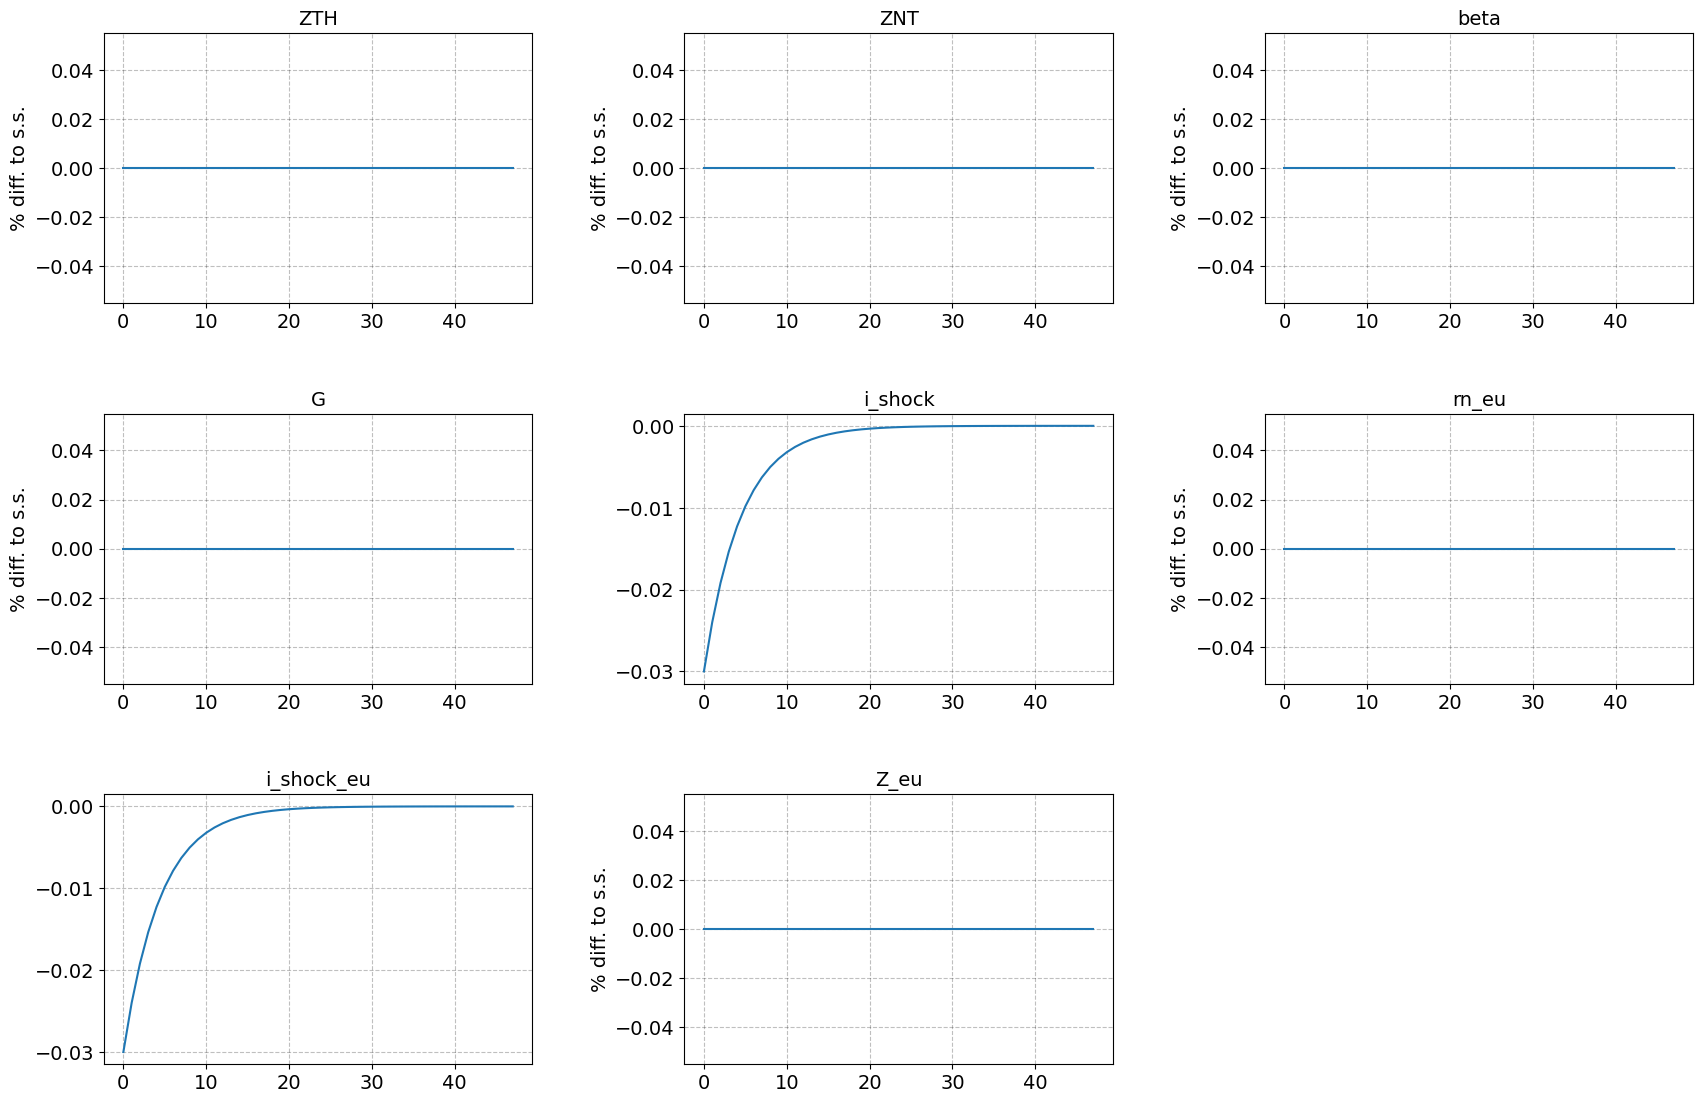


### varnames ###


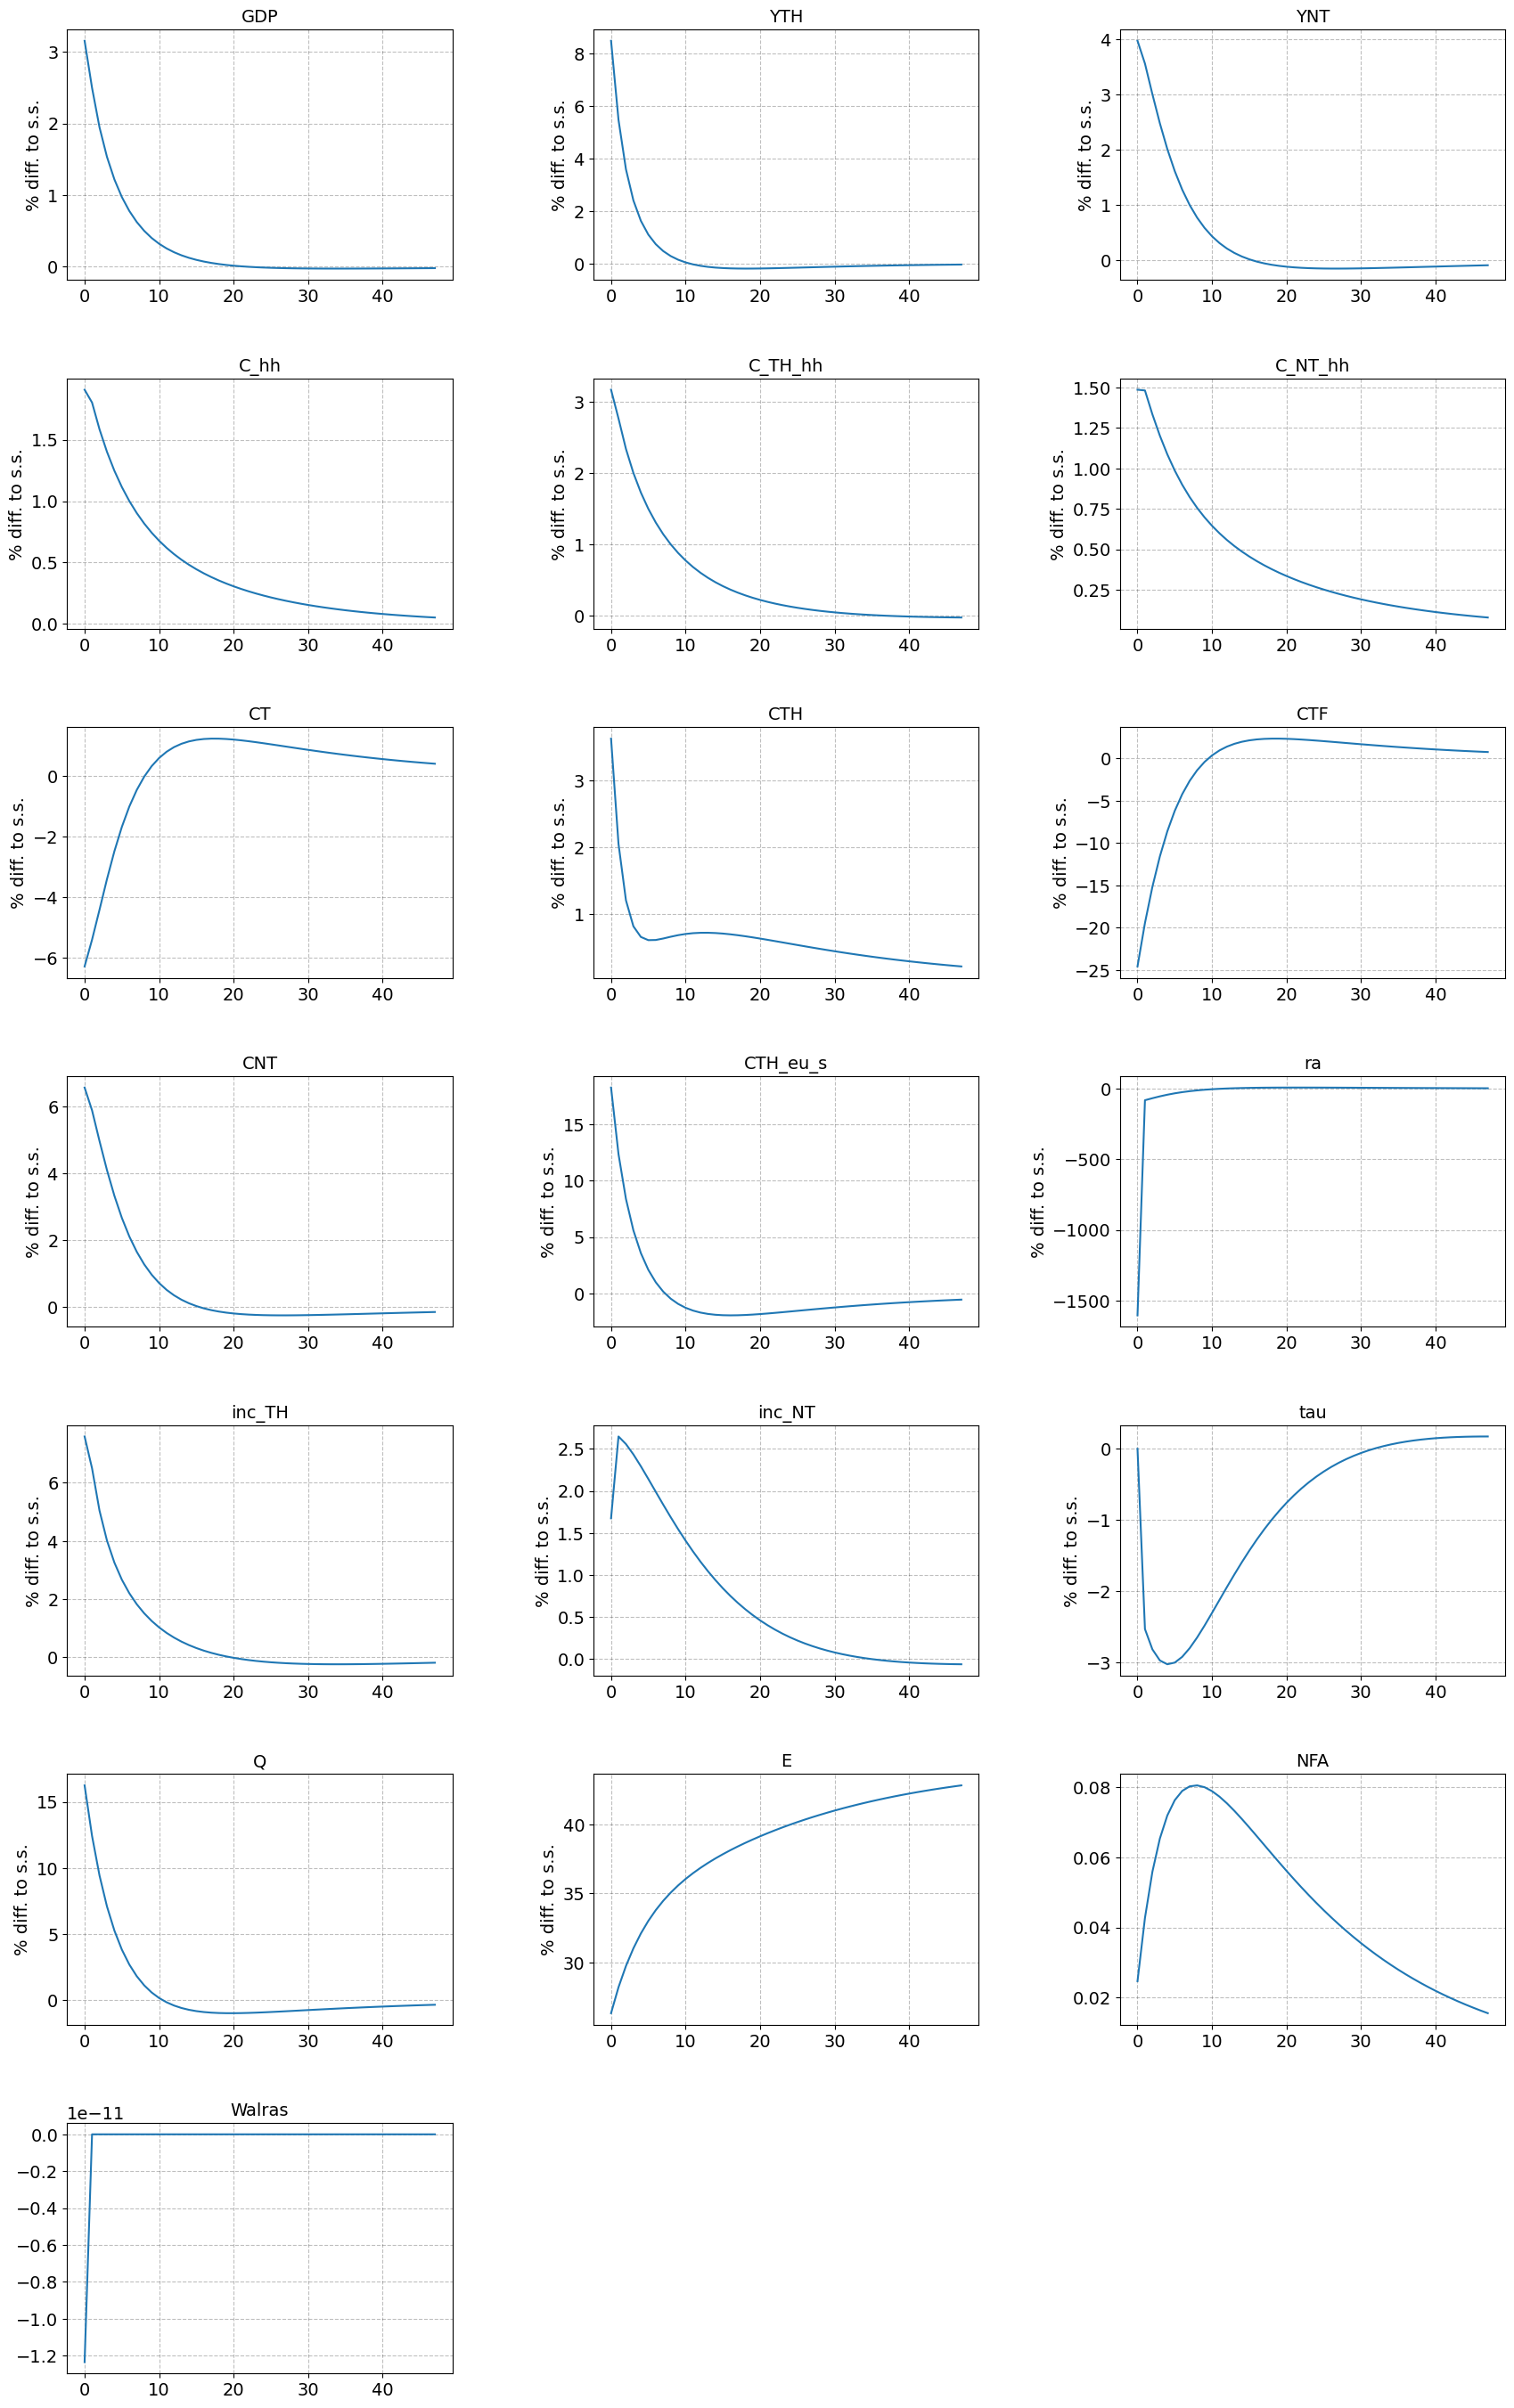


### targets ###


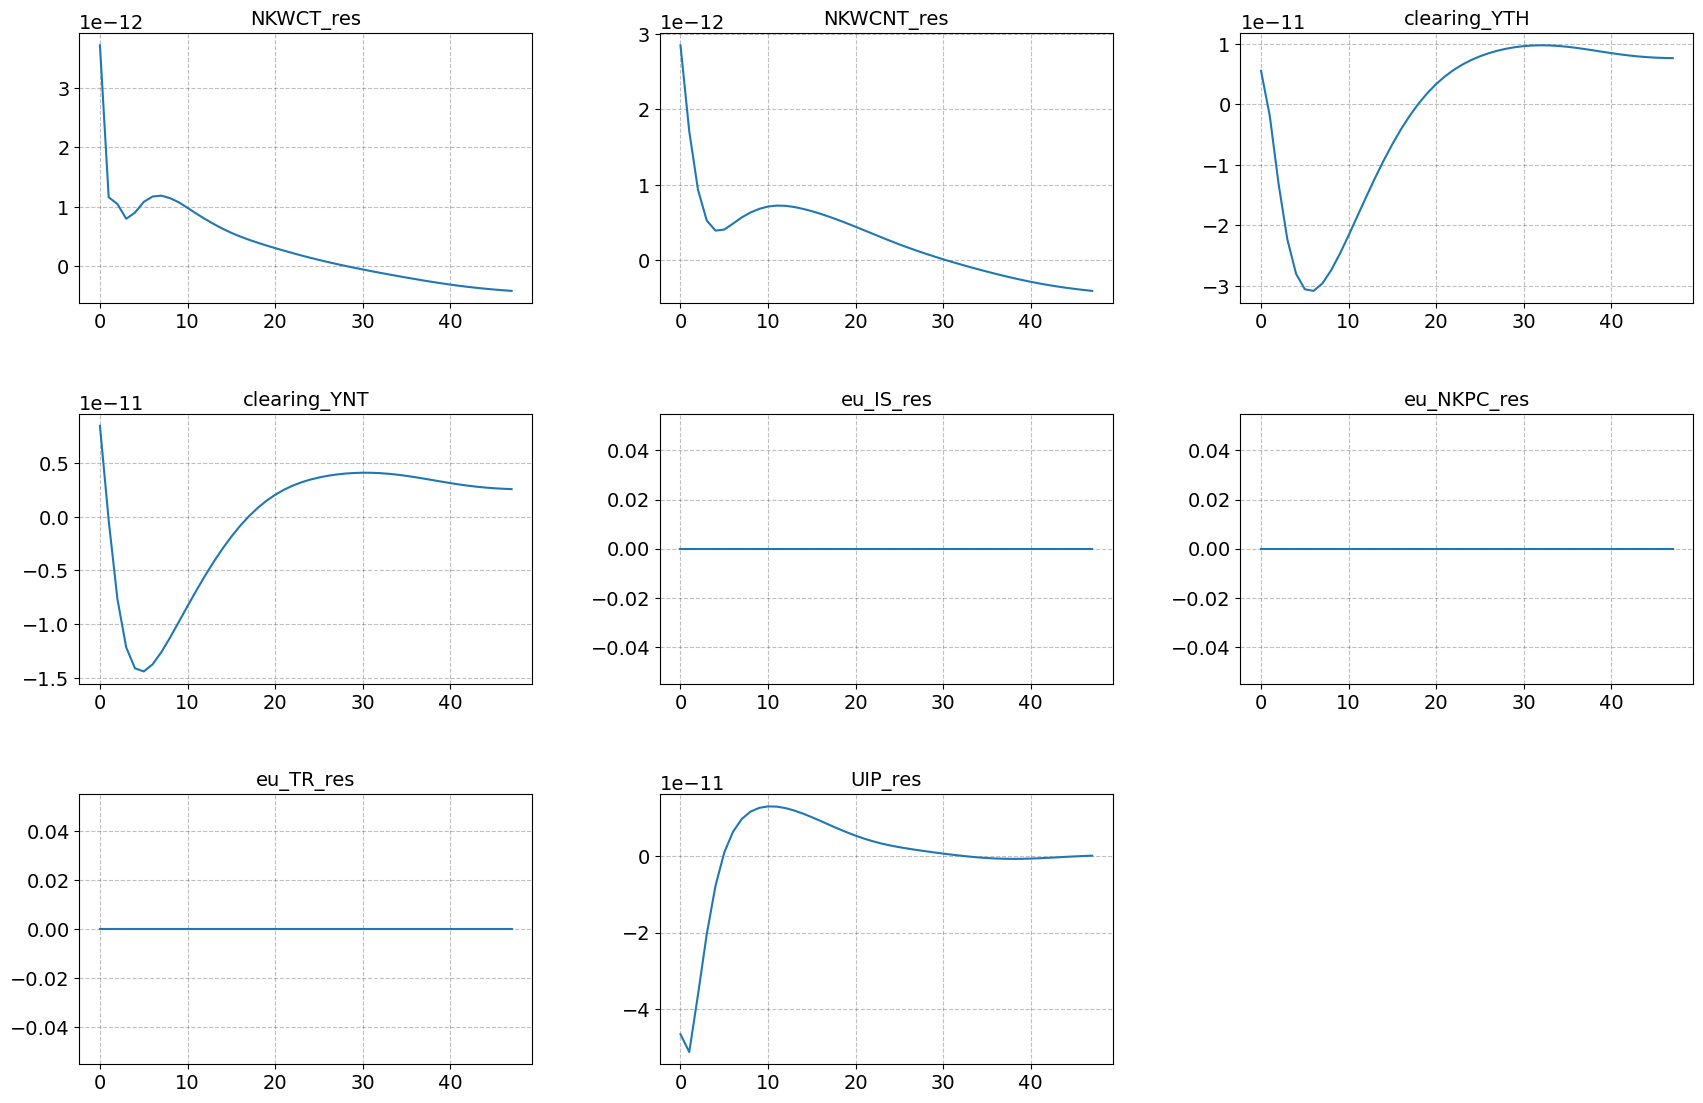

In [37]:
paths = ['GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras']
lvl_value=['r','NFA','Walras','i_shock', 'i_shock_eu']
model.show_IRFs(paths,lvl_value=lvl_value,T_max=48,ncols=3)

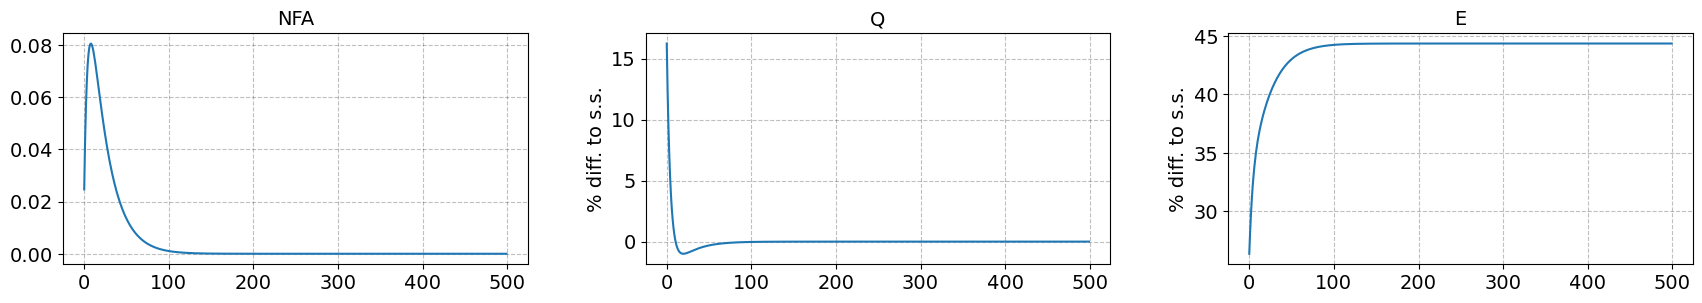

In [38]:
model.show_IRFs(['NFA','Q','E'],lvl_value=lvl_value,T_max=500,ncols=3,do_shocks=False,do_targets=False)

## 5. <a id='toc5_'></a>[Response in consumption to different shocks](#toc0_)

Foreign demand shock:

In [47]:
M_s = model.copy()
#M_s.par.jump_M_eu_s = -0.0075 # initial jump
#M_s.par.rho_M_eu_s = 0.80 # AR(1) coefficeint

M_s.par.jump_i_shock_eu = -0.01 # initial jump
M_s.par.rho_i_shock_eu= 0.80 # AR(1) coefficeint

M_s.find_transition_path(shocks=['i_shock_eu'],do_print=False,do_end_check=False)

Domestic Beta shock:

In [40]:
beta = model.copy()
beta.par.jump_beta = 0.01 # initial jump
beta.par.rho_beta = 0.80 # AR(1) coefficeint

beta.find_transition_path(shocks=['beta'],do_print=False,do_end_check=False)

Domestic G shock:

In [41]:
G = model.copy()
G.par.jump_G = -0.025 # initial jump
G.par.rho_G = 0.80 # AR(1) coefficeint

G.find_transition_path(shocks=['G'],do_print=False,do_end_check=False)

Domestic i shock:

In [48]:
i_shock_model = model.copy()
M_s.par.jump_i_shock = -0.01 # initial jump
M_s.par.rho_i_shock= 0.80 # AR(1) coefficeint

i_shock_model.find_transition_path(shocks=['i_shock'],do_print=False,do_end_check=False)

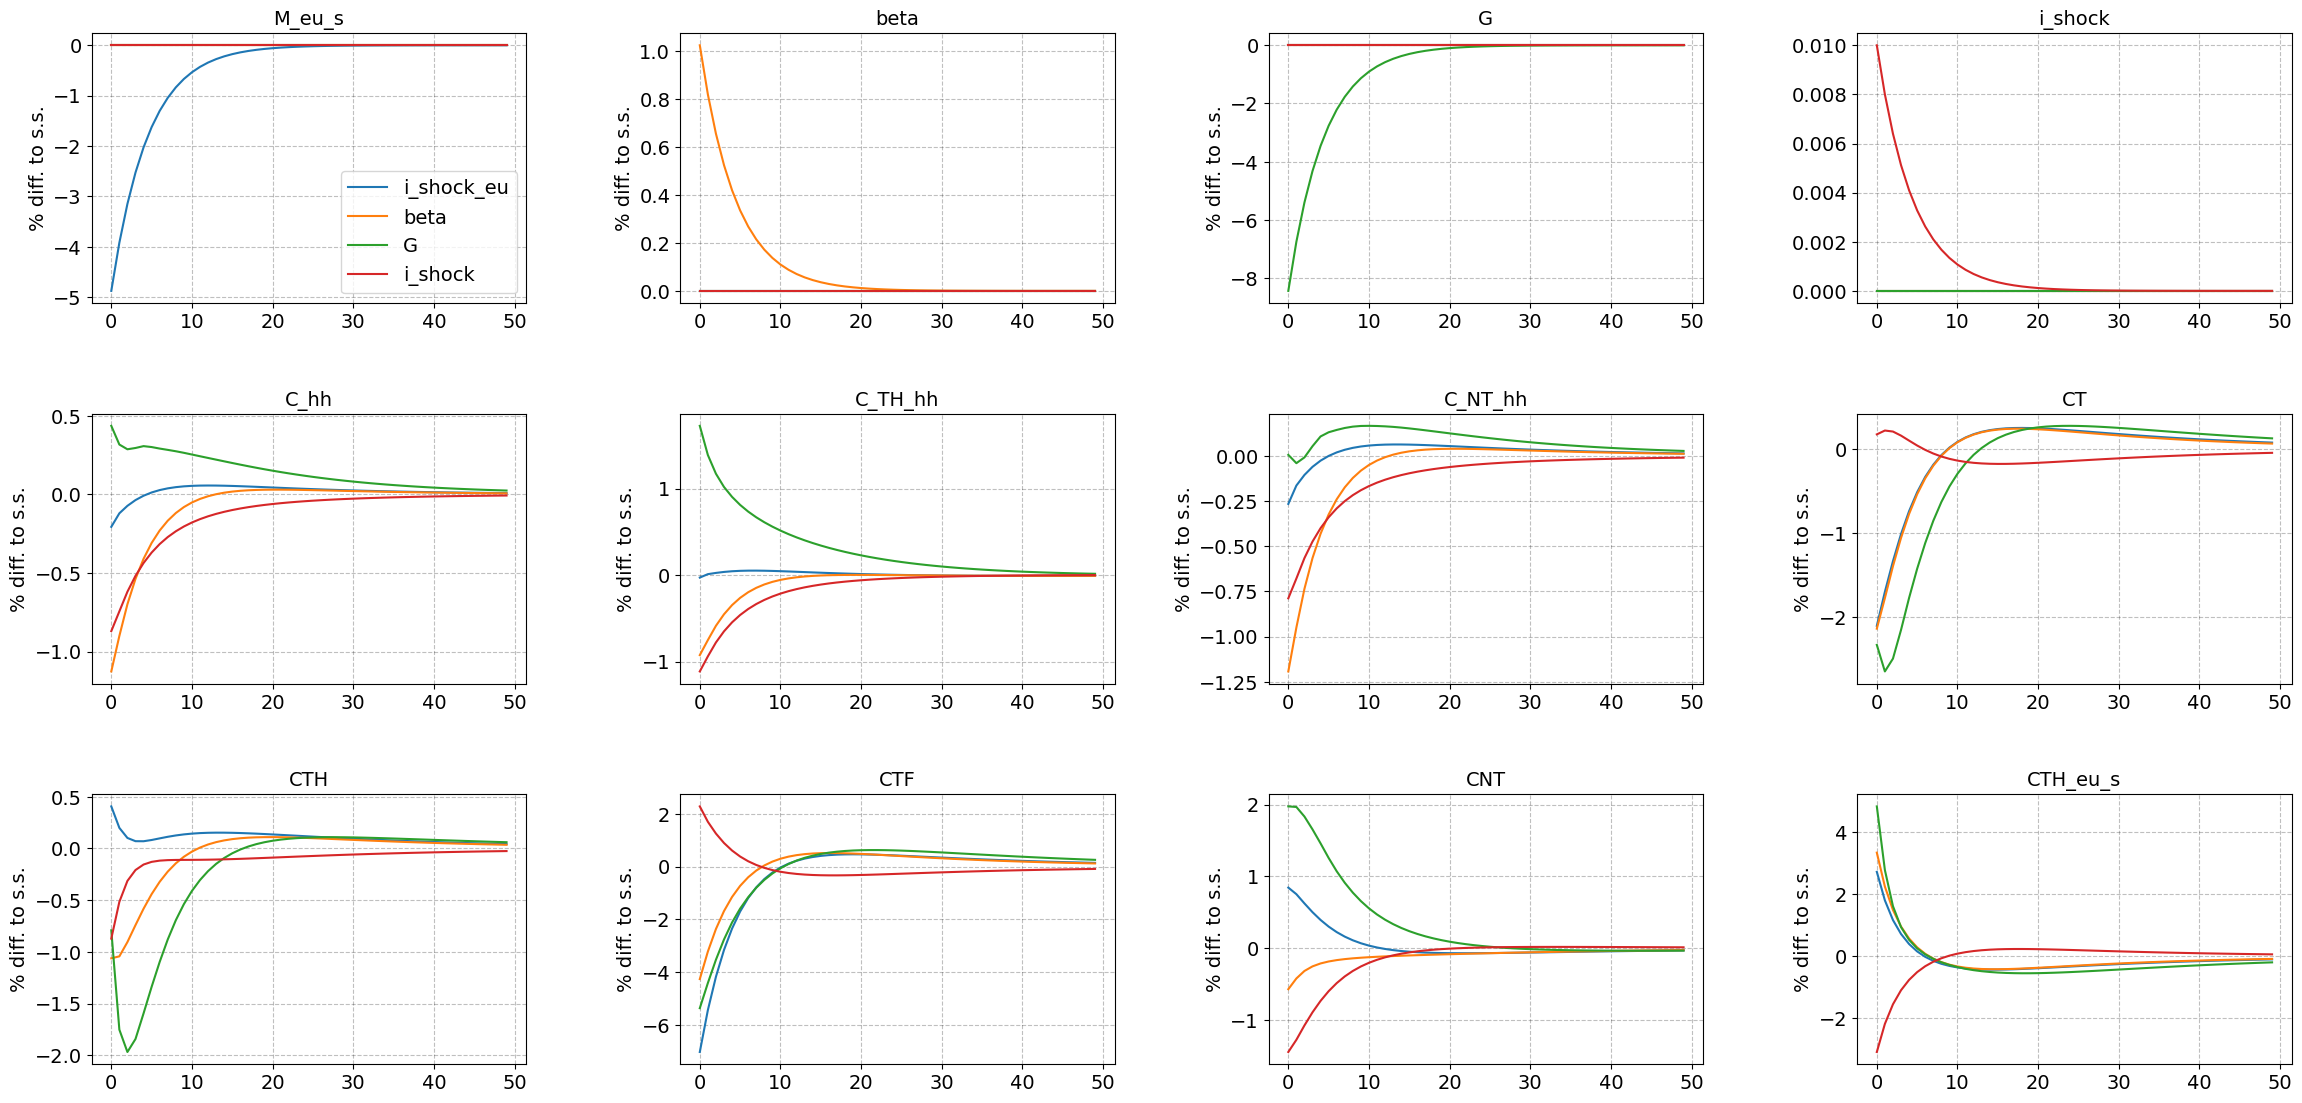

In [49]:
models = [M_s,beta,G,i_shock_model]
labels = ['i_shock_eu','beta','G','i_shock']
model.compare_IRFs(models,labels,varnames=['M_eu_s','beta','G','i_shock','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 6. <a id='toc6_'></a>[Decomposing consumption response](#toc0_)

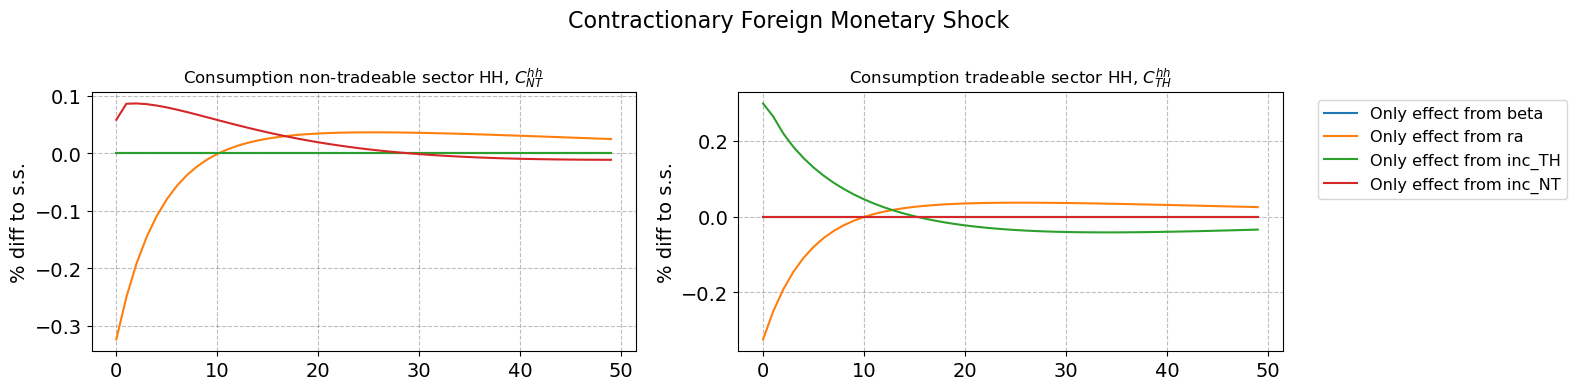

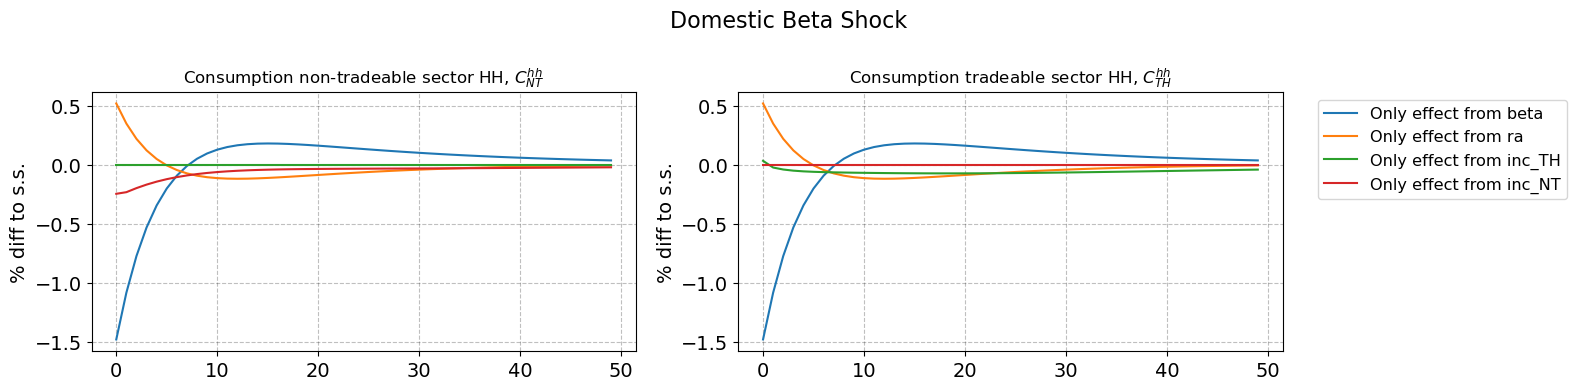

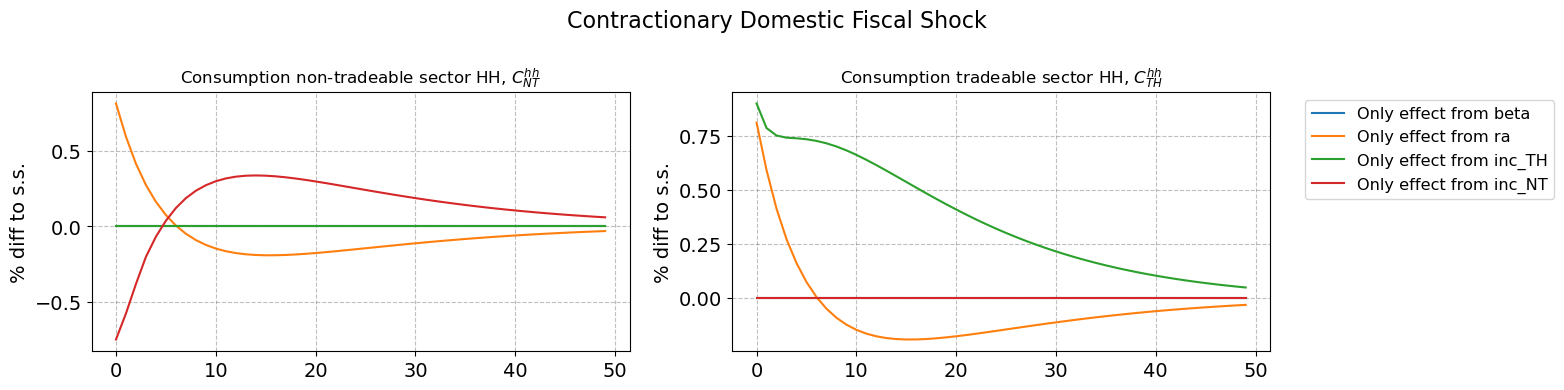

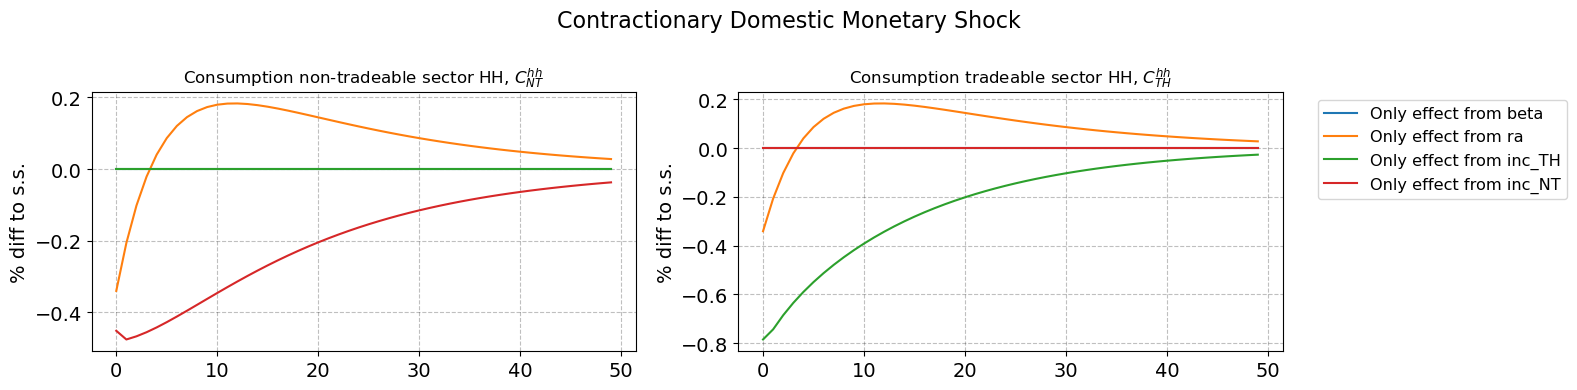

In [50]:
models = {'i_shock_eu': M_s, 'beta': beta, 'G': G, 'i_shock': i_shock_model}

model_titles = {
    'i_shock_eu': 'Contractionary Foreign Monetary Shock',
    'beta': 'Domestic Beta Shock',
    'G': 'Contractionary Domestic Fiscal Shock',
    'i_shock': 'Contractionary Domestic Monetary Shock'
}

for model_name, model in models.items():

    T_max = 50

    fig, (ax_C_NT, ax_C_TH) = plt.subplots(1, 2, figsize=(16, 4), dpi=100)
    fig.suptitle(f'{model_titles[model_name]}', fontsize=16)

    ax_C_NT.set_title('Consumption non-tradeable sector HH, $C_{NT}^{hh}$', fontsize=12)
    ax_C_TH.set_title('Consumption tradeable sector HH, $C_{TH}^{hh}$', fontsize=12)

    i_color = 0

    for use_inputs in [[x] for x in model.inputs_hh]:

        # a. compute
        path_alt = model.decompose_hh_path(do_print=False, use_inputs=use_inputs)

        # b. plot
        if use_inputs is None:
            label = 'No inputs'
            ls = '--'
            color = 'black'
        elif use_inputs == 'all':
            label = 'All inputs'
            ls = '-'
            color = 'black'
        else:
            label = f'Only effect from {use_inputs[0]}'
            ls = '-'
            color = f'C{i_color}' # use color index directly
            i_color += 1

        ax_C_NT.plot((path_alt.C_NT_hh[:T_max] / ss.C_NT_hh - 1) * 100, ls=ls, color=color, label=label)
        ax_C_TH.plot((path_alt.C_TH_hh[:T_max] / ss.C_TH_hh - 1) * 100, ls=ls, color=color, label=label)

    for ax in [ax_C_NT, ax_C_TH]:
        ax.set_ylabel('% diff to s.s.')
        lgd = ax_C_TH.legend(frameon=True, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()


## 7. <a id='toc7_'></a>[Fixed vs floating exchange rate](#toc0_)

In [46]:
fixed = model.copy()
fixed.par.float = False
fixed.find_ss()
fixed.compute_jacs()

Foreign demand shock:

In [52]:
M_s_fixed = fixed.copy()
M_s_fixed.par.jump_i_shock_eu = -0.01 # initial jump
M_s_fixed.par.rho_i_shock_eu= 0.80 # AR(1) coefficeint

#M_s_fixed.par.jump_rF = -0.00005 # initial jump
#M_s_fixed.par.rho_rF = 0.80 # AR(1) coefficeint

#M_s_fixed.par.jump_PF_s = -0.03 # initial jump
#M_s_fixed.par.rho_PF_s = 0.80 # AR(1) coefficeint

M_s_fixed.find_transition_path(shocks=['i_shock_eu'])

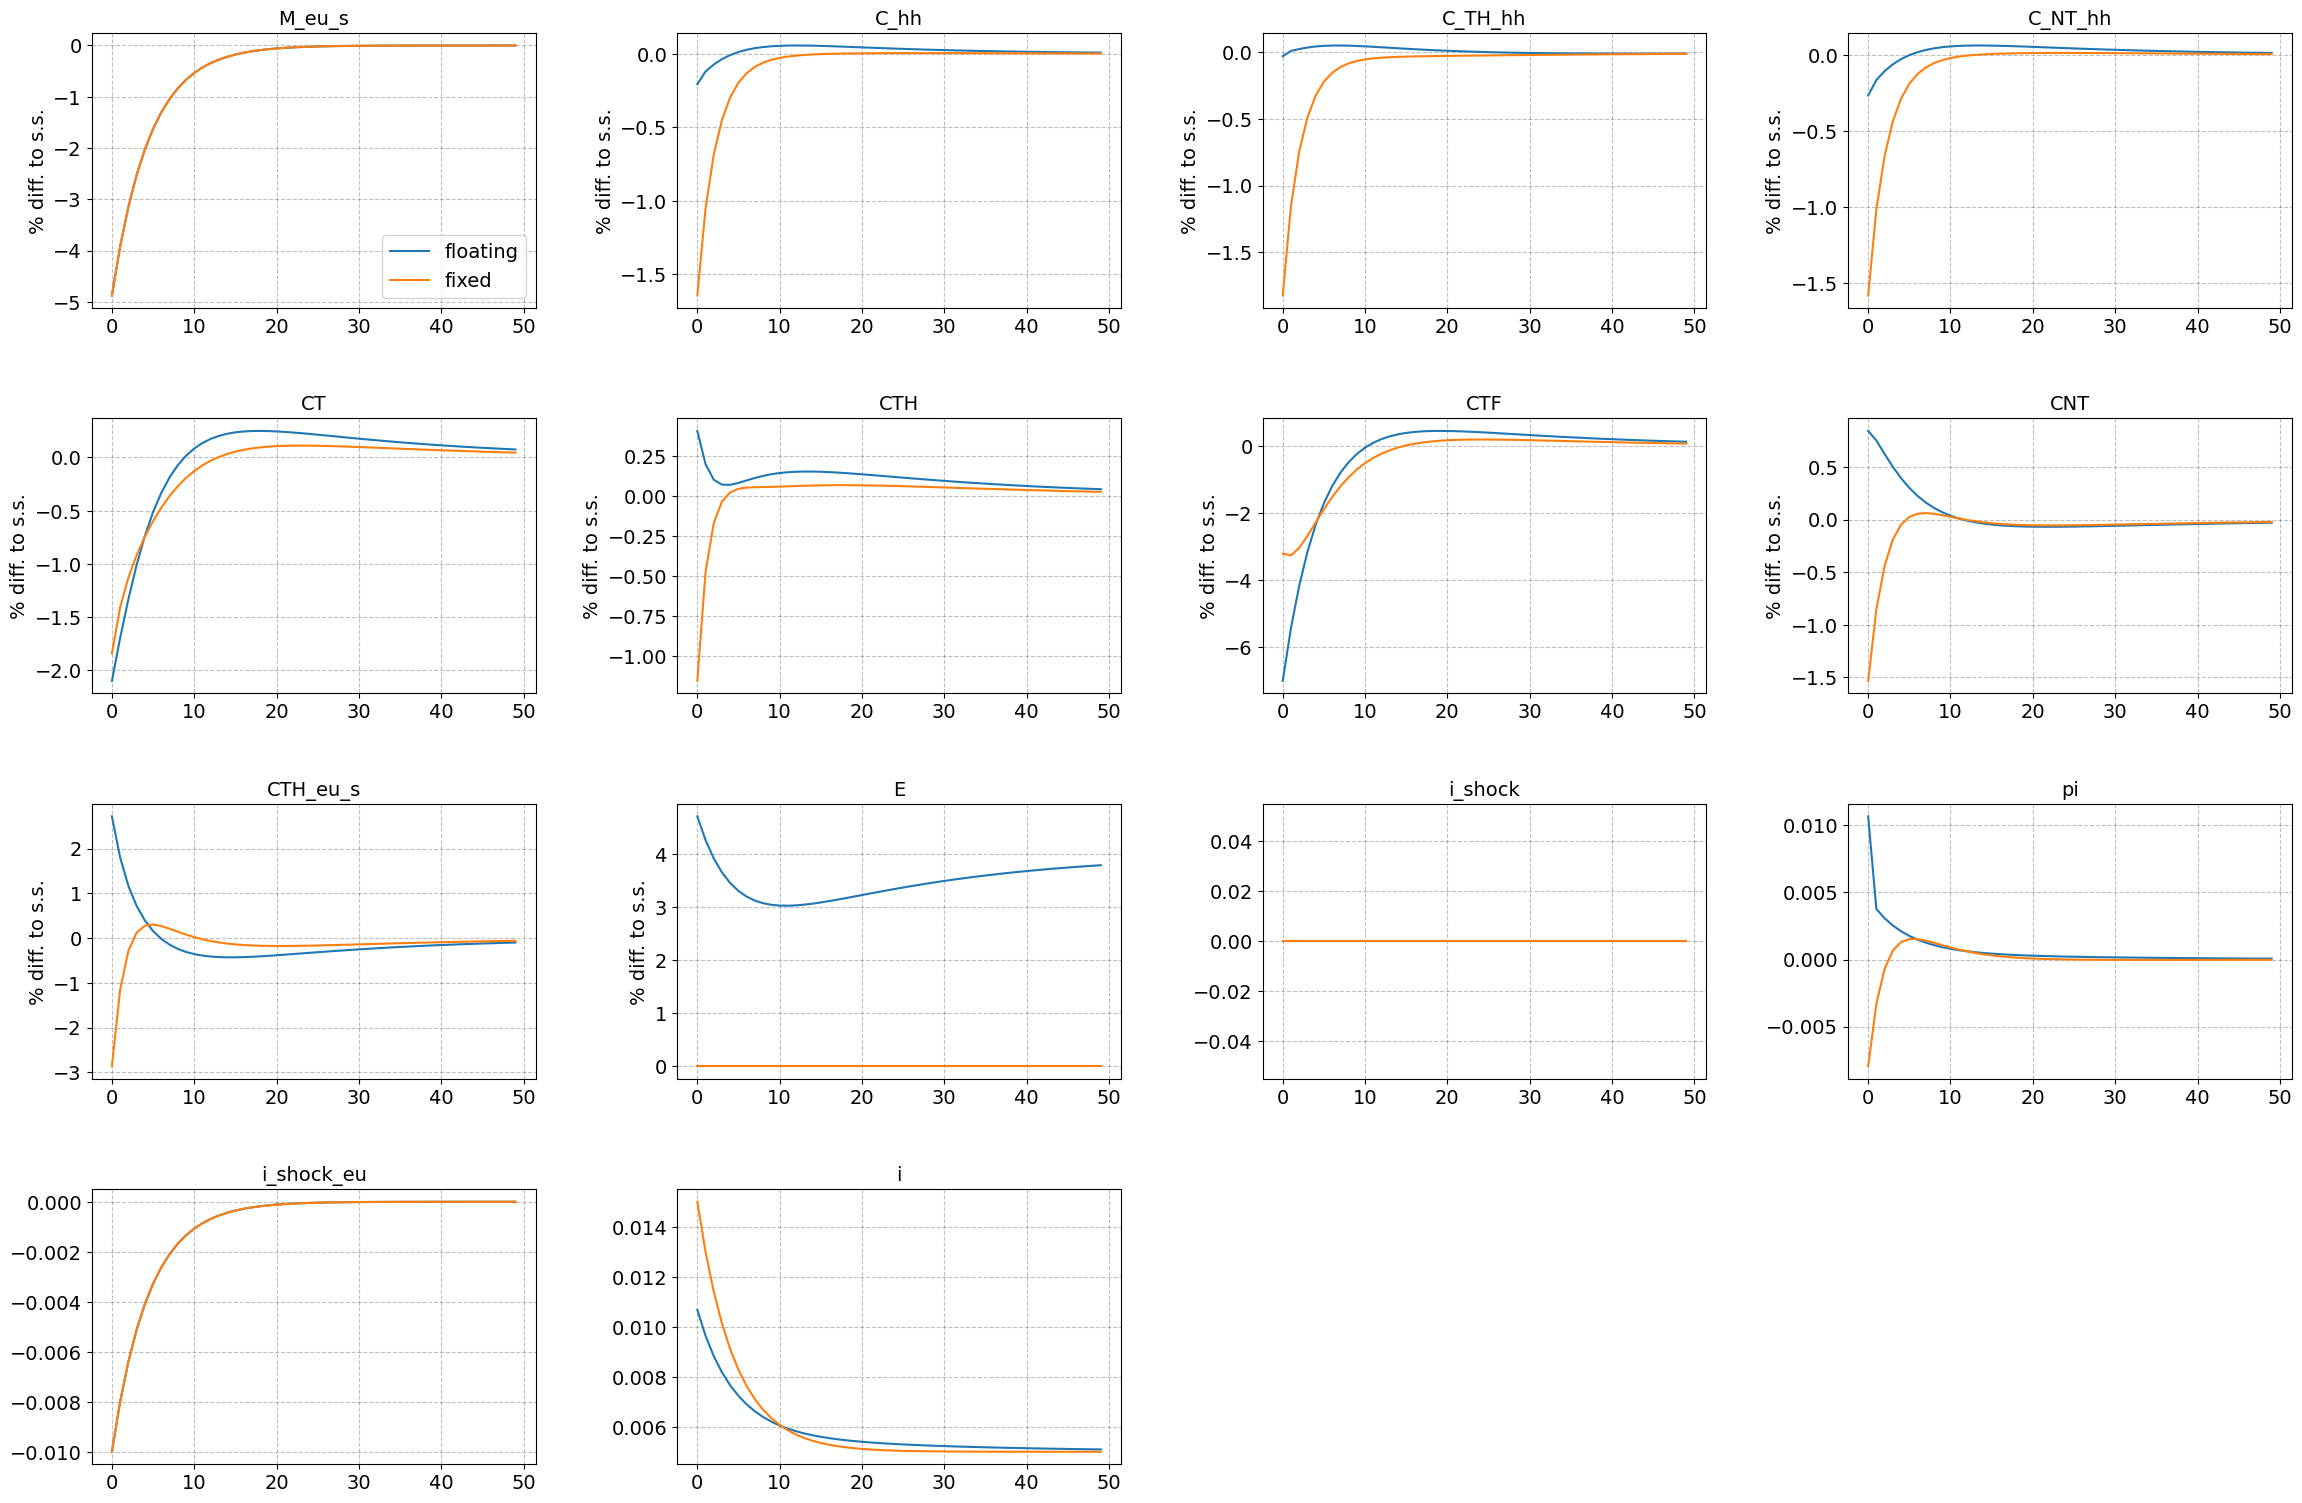

In [55]:
models = [M_s,M_s_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['M_eu_s','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','E','i_shock','pi', 'i_shock_eu','i'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock','pi', 'i_shock_eu','i'],T_max=50)

Domestic beta shock:

In [ ]:
beta_fixed = fixed.copy()
beta_fixed.par.jump_beta = 0.01 # initial jump
beta_fixed.par.rho_beta = 0.80 # AR(1) coefficeint

beta_fixed.find_transition_path(shocks=['beta'])

In [ ]:
models = [beta,beta_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['beta','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','i','E'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

Domestic G shock:

In [ ]:
G_fixed = fixed.copy()
G_fixed.par.jump_G = -0.025 # initial jump
G_fixed.par.rho_G = 0.80 # AR(1) coefficeint

G_fixed.find_transition_path(shocks=['G'])

In [ ]:
models = [G,G_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['G','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','i','E'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 8. <a id='toc8_'></a>[Decomposing consumption response under fixed exchange rate](#toc0_)

In [ ]:
models = {'M_s': M_s_fixed, 'beta': beta_fixed, 'G': G_fixed}

model_titles = {
    'M_s': 'Foreign Demand Shock',
    'beta': 'Domestic Beta Shock',
    'G': 'Contractionary Domestic Fiscal Shock'   
}

for model_name, model in models.items():

    T_max = 50

    fig, (ax_C_NT, ax_C_TH) = plt.subplots(1, 2, figsize=(16, 4), dpi=100)
    fig.suptitle(f'{model_titles[model_name]}', fontsize=16)

    ax_C_NT.set_title('Consumption non-tradeable sector HH, $C_{NT}^{hh}$', fontsize=12)
    ax_C_TH.set_title('Consumption tradeable sector HH, $C_{TH}^{hh}$', fontsize=12)

    i_color = 0

    for use_inputs in [[x] for x in model.inputs_hh]:

        # a. compute
        path_alt = model.decompose_hh_path(do_print=False, use_inputs=use_inputs)

        # b. plot
        if use_inputs is None:
            label = 'No inputs'
            ls = '--'
            color = 'black'
        elif use_inputs == 'all':
            label = 'All inputs'
            ls = '-'
            color = 'black'
        else:
            label = f'Only effect from {use_inputs[0]}'
            ls = '-'
            color = f'C{i_color}' # use color index directly
            i_color += 1

        ax_C_NT.plot((path_alt.C_NT_hh[:T_max] / ss.C_NT_hh - 1) * 100, ls=ls, color=color, label=label)
        ax_C_TH.plot((path_alt.C_TH_hh[:T_max] / ss.C_TH_hh - 1) * 100, ls=ls, color=color, label=label)

    for ax in [ax_C_NT, ax_C_TH]:
        ax.set_ylabel('% diff to s.s.')
        lgd = ax_C_TH.legend(frameon=True, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()
